In [ ]:
DSC530
Sara Rinaldo
Term Project

In [ ]:
# HYPOTHESIS

In [ ]:
# Hypothesis: There is a significant correlation between time spend on social media (Daily_Usage_Time and the level
# of engagement (Posts_Per_Day, Likes_Received_Per_Day, Comments_Received_Per_Day and Messages_Sent_Per_Day.

# This hypothesis aims to explore whether more time spent on social media leads to higher engagement in terms of posting, messages,
# comments and likes.

In [ ]:
# INITIAL EDA

In [ ]:
# Variables
# Daily_Usage_Time (minutes): The average time spent by user on social media measured in minutes.  This is a numerical variable.
# Posts_Per_Day: The average number of posts the user makes per day.  This is a numerical variable. 
# Likes_Received_Per_Day: The average number of likes the user's posts receiver per day.  This is a numerical variable.  
# Comments_Received_Per_Day: The average number of comments the user's posts receive per day.  This is a numerical variable.
# Messages_Sent_Per_Day: The average number of messages the user sends per day.  This is a numerical variable.  

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv("C:\\Users\\czarn\\530\\train.csv", on_bad_lines='skip')
# Drop blank lines in file
data = data.dropna(how='all')
# Display the first few rows
print(data.head())

  User_ID Age      Gender   Platform  Daily_Usage_Time (minutes)  \
1       1  25      Female  Instagram                       120.0   
3       2  30        Male    Twitter                        90.0   
5       3  22  Non-binary   Facebook                        60.0   
7       4  28      Female  Instagram                       200.0   
9       5  33        Male   LinkedIn                        45.0   

   Posts_Per_Day  Likes_Received_Per_Day  Comments_Received_Per_Day  \
1            3.0                    45.0                       10.0   
3            5.0                    20.0                       25.0   
5            2.0                    15.0                        5.0   
7            8.0                   100.0                       30.0   
9            1.0                     5.0                        2.0   

   Messages_Sent_Per_Day Dominant_Emotion  
1                   12.0        Happiness  
3                   30.0            Anger  
5                   20.0        

In [2]:
# Display summary information
print(data.info)

<bound method DataFrame.info of      User_ID Age      Gender   Platform  Daily_Usage_Time (minutes)  \
1          1  25      Female  Instagram                       120.0   
3          2  30        Male    Twitter                        90.0   
5          3  22  Non-binary   Facebook                        60.0   
7          4  28      Female  Instagram                       200.0   
9          5  33        Male   LinkedIn                        45.0   
...      ...  ..         ...        ...                         ...   
1995     996  33  Non-binary    Twitter                        85.0   
1997     997  22      Female   Facebook                        70.0   
1999     998  35        Male   Whatsapp                       110.0   
2001     999  28  Non-binary   Telegram                        60.0   
2003    1000  27      Female   Snapchat                       120.0   

      Posts_Per_Day  Likes_Received_Per_Day  Comments_Received_Per_Day  \
1               3.0                    45

In [3]:
# Display summary statistics
print(data.describe(include='all'))

       User_ID   Age  Gender   Platform  Daily_Usage_Time (minutes)  \
count     1001  1001    1000       1000                 1000.000000   
unique    1001    19      18          7                         NaN   
top          1    28  Female  Instagram                         NaN   
freq         1    92     344        250                         NaN   
mean       NaN   NaN     NaN        NaN                   95.950000   
std        NaN   NaN     NaN        NaN                   38.850442   
min        NaN   NaN     NaN        NaN                   40.000000   
25%        NaN   NaN     NaN        NaN                   65.000000   
50%        NaN   NaN     NaN        NaN                   85.000000   
75%        NaN   NaN     NaN        NaN                  120.000000   
max        NaN   NaN     NaN        NaN                  200.000000   

        Posts_Per_Day  Likes_Received_Per_Day  Comments_Received_Per_Day  \
count     1000.000000             1000.000000                1000.00000

In [7]:
# Check for missing values and duplicates in the data and ensured that data types were appropriate for each variable

In [9]:
# Check for missing values
print(data.isnull().sum())

User_ID                       0
Age                           0
Gender                        1
Platform                      1
Daily_Usage_Time (minutes)    1
Posts_Per_Day                 1
Likes_Received_Per_Day        1
Comments_Received_Per_Day     1
Messages_Sent_Per_Day         1
Dominant_Emotion              1
dtype: int64


In [11]:
# Remove duplicates
print(data.duplicated().sum())

0


In [13]:
# Show Field Data Types
print(data.dtypes)

User_ID                        object
Age                            object
Gender                         object
Platform                       object
Daily_Usage_Time (minutes)    float64
Posts_Per_Day                 float64
Likes_Received_Per_Day        float64
Comments_Received_Per_Day     float64
Messages_Sent_Per_Day         float64
Dominant_Emotion               object
dtype: object


In [19]:
# Remove NAs
data_clean=data.dropna()
# Show the cleaned data
print(data_clean.head())

  User_ID Age      Gender   Platform  Daily_Usage_Time (minutes)  \
1       1  25      Female  Instagram                       120.0   
3       2  30        Male    Twitter                        90.0   
5       3  22  Non-binary   Facebook                        60.0   
7       4  28      Female  Instagram                       200.0   
9       5  33        Male   LinkedIn                        45.0   

   Posts_Per_Day  Likes_Received_Per_Day  Comments_Received_Per_Day  \
1            3.0                    45.0                       10.0   
3            5.0                    20.0                       25.0   
5            2.0                    15.0                        5.0   
7            8.0                   100.0                       30.0   
9            1.0                     5.0                        2.0   

   Messages_Sent_Per_Day Dominant_Emotion  
1                   12.0        Happiness  
3                   30.0            Anger  
5                   20.0        

In [ ]:
# HISTOGRAMS

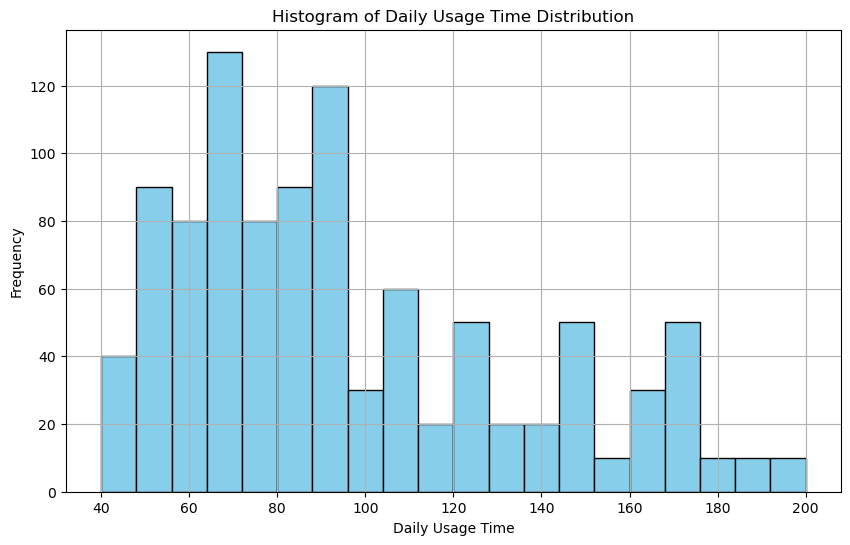

In [21]:
# Create histogram of Daily Usage Time
plt.figure(figsize=(10,6))
plt.hist(data_clean['Daily_Usage_Time (minutes)'],bins=20,color='skyblue',edgecolor='black')
plt.title('Histogram of Daily Usage Time Distribution')
plt.xlabel('Daily Usage Time')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
# The histogram is bmodal with peaks around 70 and 90.  Most users post between 60-120 minutes on social media daily.
# Data points over 180 minutes could be considered outliers, but will be left in the data to avoid skewing.

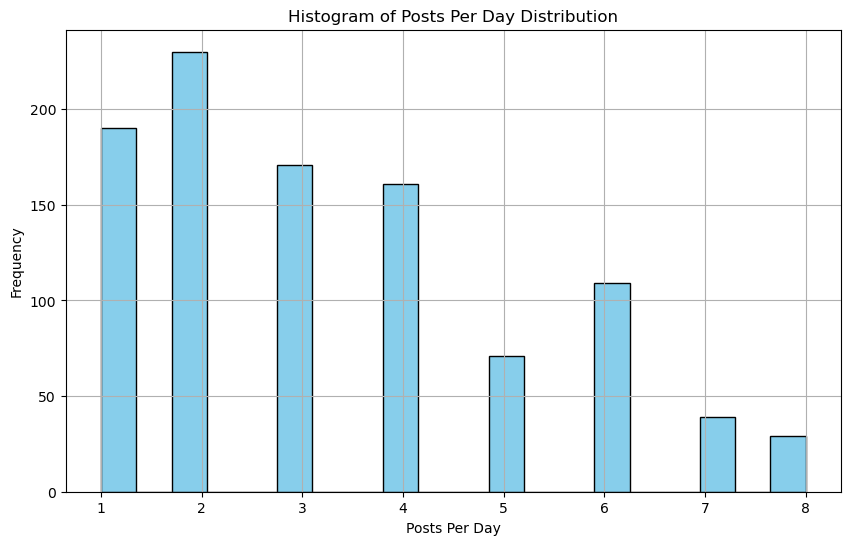

In [23]:
# Create histogram of Posts Per Day
plt.figure(figsize=(10,6))
plt.hist(data_clean['Posts_Per_Day'],bins=20,color='skyblue',edgecolor='black')
plt.title('Histogram of Posts Per Day Distribution')
plt.xlabel('Posts Per Day')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
# The histogram is right skewed. Most users post 1-4 times a day with the most common being 2 times per day.
# Over 7-8 posts per day could be considered outliers, but will be kept to understand the full scope of the data.

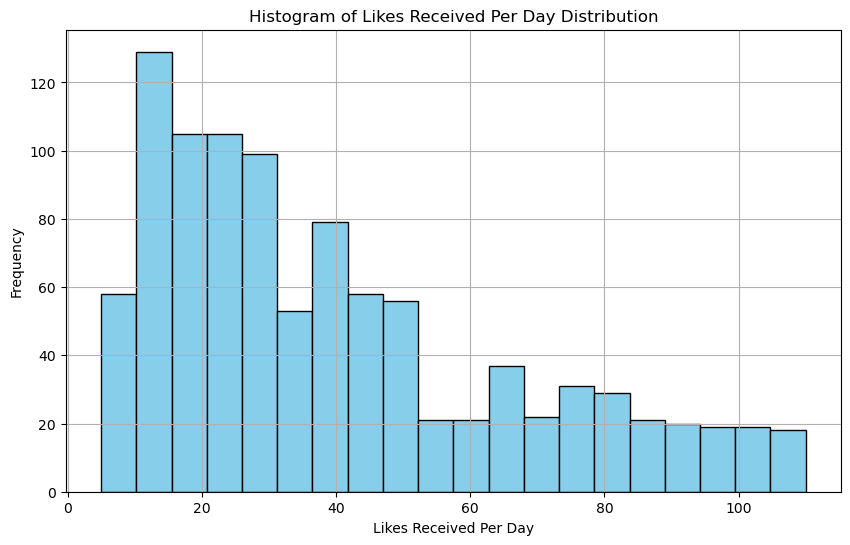

In [25]:
# Create histogram of Likes Received Per Day
plt.figure(figsize=(10,6))
plt.hist(data_clean['Likes_Received_Per_Day'],bins=20,color='skyblue',edgecolor='black')
plt.title('Histogram of Likes Received Per Day Distribution')
plt.xlabel('Likes Received Per Day')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
# The histogram is right skewed.  Most users receive 10-40 likes per day with the highest bar being around 15.
# Above 60 likes per day oculd be considered outliers, but will be kept in the data to determine high engagement.

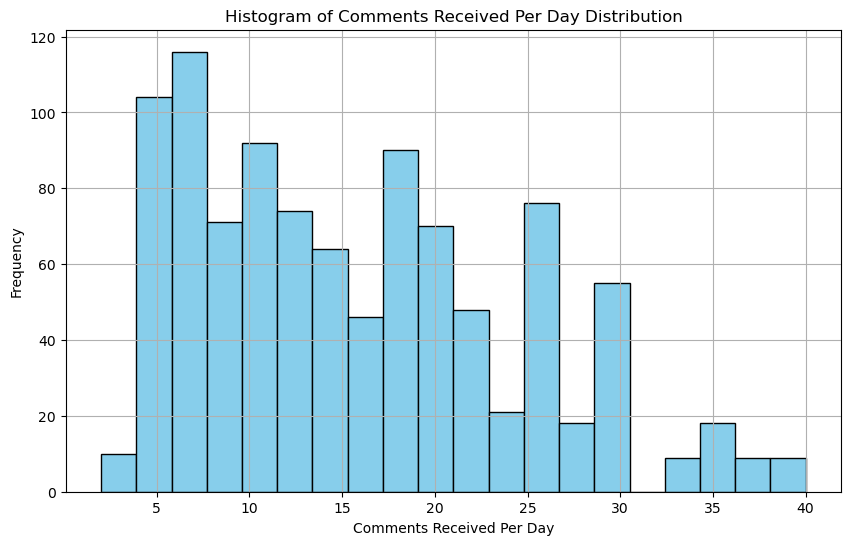

In [128]:
# Create histogram of Comments Received Per Day
plt.figure(figsize=(10,6))
plt.hist(data_clean['Comments_Received_Per_Day'],bins=20,color='skyblue',edgecolor='black')
plt.title('Histogram of Comments Received Per Day Distribution')
plt.xlabel('Comments Received Per Day')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
# The histogram is multimodal with several peaks.  Most users get 5-15 comments per day with the highest bar around 7.
# 30-40 comments per day could be considered outliers, but will be kept in the data to understand highly engaged users.

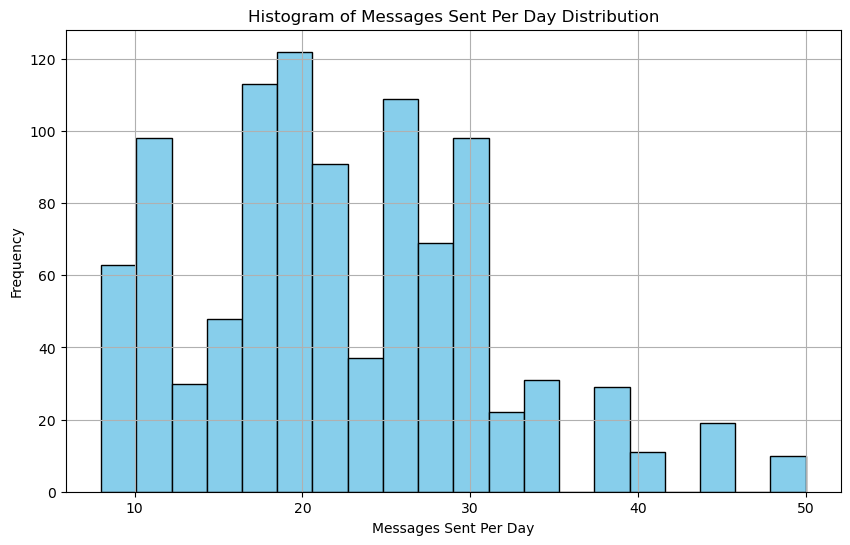

In [29]:
# # Create histogram of Messages Sent Per Day
plt.figure(figsize=(10,6))
plt.hist(data_clean['Messages_Sent_Per_Day'],bins=20,color='skyblue',edgecolor='black')
plt.title('Histogram of Messages Sent Per Day Distribution')
plt.xlabel('Messages Sent Per Day')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
# The histogram is multimodal with several peaks. Most users send 10-30 messages a day with the highest peak around 20.
# Messages sent above 40 per day could be considered outliers, but will be kept in the data for insights on user engagement.

In [ ]:
# SUMMARY STATISTICS

In [31]:
# Calculate and display mean, mode, standard deviation, min, max, and percentiles for daily usage time 
usage_mean = data_clean['Daily_Usage_Time (minutes)'].mean()
usage_mode = data_clean['Daily_Usage_Time (minutes)'].mode()[0]
usage_std = data_clean['Daily_Usage_Time (minutes)'].std()
usage_min = data_clean['Daily_Usage_Time (minutes)'].min()
usage_max = data_clean['Daily_Usage_Time (minutes)'].max()
usage_percentiles = data_clean['Daily_Usage_Time (minutes)'].quantile([0.25,0.5,0.75])
print(f"""Usage - Mean: {usage_mean}, Mode: {usage_mode}, Std: {usage_std}, Min: {usage_min}, Max: {usage_max},
25th Percentile: {usage_percentiles[0.25]}, 50th Percentile: {usage_percentiles[0.5]}, 75th Percentile: {usage_percentiles[0.75]}""")

Usage - Mean: 95.95, Mode: 60.0, Std: 38.85044217067388, Min: 40.0, Max: 200.0,
25th Percentile: 65.0, 50th Percentile: 85.0, 75th Percentile: 120.0


In [33]:
# Calculate and display mean, mode, standard deviation, min, max, and percentiles for posts per day 
posts_per_day_mean = data_clean['Posts_Per_Day'].mean()
posts_per_day_mode = data_clean['Posts_Per_Day'].mode()[0]
posts_per_day_std = data_clean['Posts_Per_Day'].std()
posts_per_day_min = data_clean['Posts_Per_Day'].min()
posts_per_day_max = data_clean['Posts_Per_Day'].max()
posts_per_day_percentiles = data_clean['Posts_Per_Day'].quantile([0.25,0.5,0.75])
print(f"""Posts per Day - Mean: {posts_per_day_mean}, Mode: {posts_per_day_mode}, Std: {posts_per_day_std}, Min: {posts_per_day_min}, Max: {posts_per_day_max},
25th Percentile: {posts_per_day_percentiles[0.25]}, 50th Percentile: {posts_per_day_percentiles[0.5]}, 75th Percentile: {posts_per_day_percentiles[0.75]}""")

Posts per Day - Mean: 3.321, Mode: 2.0, Std: 1.9145821018239513, Min: 1.0, Max: 8.0,
25th Percentile: 2.0, 50th Percentile: 3.0, 75th Percentile: 4.0


In [35]:
# Calculate and display mean, mode, standard deviation, min, max, and percentiles for likes per day
likes_per_day_mean = data_clean['Likes_Received_Per_Day'].mean()
likes_per_day_mode = data_clean['Likes_Received_Per_Day'].mode()[0]
likes_per_day_std = data_clean['Likes_Received_Per_Day'].std()
likes_per_day_min = data_clean['Likes_Received_Per_Day'].min()
likes_per_day_max = data_clean['Likes_Received_Per_Day'].max()
likes_per_day_percentiles = data_clean['Likes_Received_Per_Day'].quantile([0.25,0.5,0.75])
print(f"""Likes Per Day - Mean: {likes_per_day_mean}, Mode: {likes_per_day_mode}, Std: {likes_per_day_std}, Min: {likes_per_day_min}, Max: {likes_per_day_max},
25th Percentile: {likes_per_day_percentiles[0.25]}, 50th Percentile: {likes_per_day_percentiles[0.5]}, 75th Percentile: {likes_per_day_percentiles[0.75]}""")

Likes Per Day - Mean: 39.898, Mode: 30.0, Std: 26.393867322395803, Min: 5.0, Max: 110.0,
25th Percentile: 20.0, 50th Percentile: 33.0, 75th Percentile: 55.0


In [37]:
# Calculate and display mean, mode, standard deviation, min, max, and percentiles for comments per day
comments_per_day_mean = data_clean['Comments_Received_Per_Day'].mean()
comments_per_day_mode = data_clean['Comments_Received_Per_Day'].mode()[0]
comments_per_day_std = data_clean['Comments_Received_Per_Day'].std()
comments_per_day_min = data_clean['Cmments_Received_Per_Day'].min()
comments_per_day_max = data_clean['Comments_Received_Per_Day'].max()
comments_per_day_percentiles = data_clean['Comments_Received_Per_Day'].quantile([0.25,0.5,0.75])
print(f"""Comments Per Day - Mean: {comments_per_day_mean}, Mode: {comments_per_day_mode}, Std: {comments_per_day_std}, Min: {comments_per_day_min}, Max: {comments_per_day_max},
25th Percentile: {comments_per_day_percentiles[0.25]}, 50th Percentile: {comments_per_day_percentiles[0.5]}, 75th Percentile: {comments_per_day_percentiles[0.75]}""")

Comments Per Day - Mean: 15.611, Mode: 18.0, Std: 8.819493322320875, Min: 2.0, Max: 40.0,
25th Percentile: 8.0, 50th Percentile: 14.0, 75th Percentile: 22.0


In [39]:
# Calculate and display mean, mode, standard deviation, min, max, and percentiles for messages sent per day
messages_sent_per_day_mean = data_clean['Messages_Sent_Per_Day'].mean()
messages_sent_per_day_mode = data_clean['Messages_Sent_Per_Day'].mode()[0]
messages_sent_per_day_std = data_clean['Messages_Sent_Per_Day'].std()
messages_sent_per_day_min = data_clean['Messages_Sent_Per_Day'].min()
messages_sent_per_day_max = data_clean['Messages_Sent_Per_Day'].max()
messages_sent_per_day_percentiles = data_clean['Messages_Sent_Per_Day'].quantile([0.25,0.5,0.75])
print(f"""Messages Sent Per Day - Mean: {messages_sent_per_day_mean}, Mode: {messages_sent_per_day_mode}, Std: {messages_sent_per_day_std}, Min: {messages_sent_per_day_min}, Max: {messages_sent_per_day_max},
25th Percentile: {messages_sent_per_day_percentiles[0.25]}, 50th Percentile: {messages_sent_per_day_percentiles[0.5]}, 75th Percentile: {messages_sent_per_day_percentiles[0.75]}""")

Messages Sent Per Day - Mean: 22.56, Mode: 20.0, Std: 8.51627423976746, Min: 8.0, Max: 50.0,
25th Percentile: 17.75, 50th Percentile: 22.0, 75th Percentile: 28.0


In [ ]:
# PMF

In [100]:
# Import Libraries 
import thinkstats2
import thinkplot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define high and low usage
low_usage = data_clean[data_clean['Daily_Usage_Time (minutes)'] <60]
high_usage = data_clean[data_clean['Daily_Usage_Time (minutes)'] >=60]

# Function to compute PMF
def compute_pmf(data,column):
    counts = data[column].value_counts(normalize=True).sort_index()
    pmf = counts / counts.sum()
    return pmf

# Compute PMF for low and high usage groups
pmf_low_usage = compute_pmf(low_usage, 'Posts_Per_Day')
pmf_high_usage = compute_pmf(high_usage, 'Posts_Per_Day')

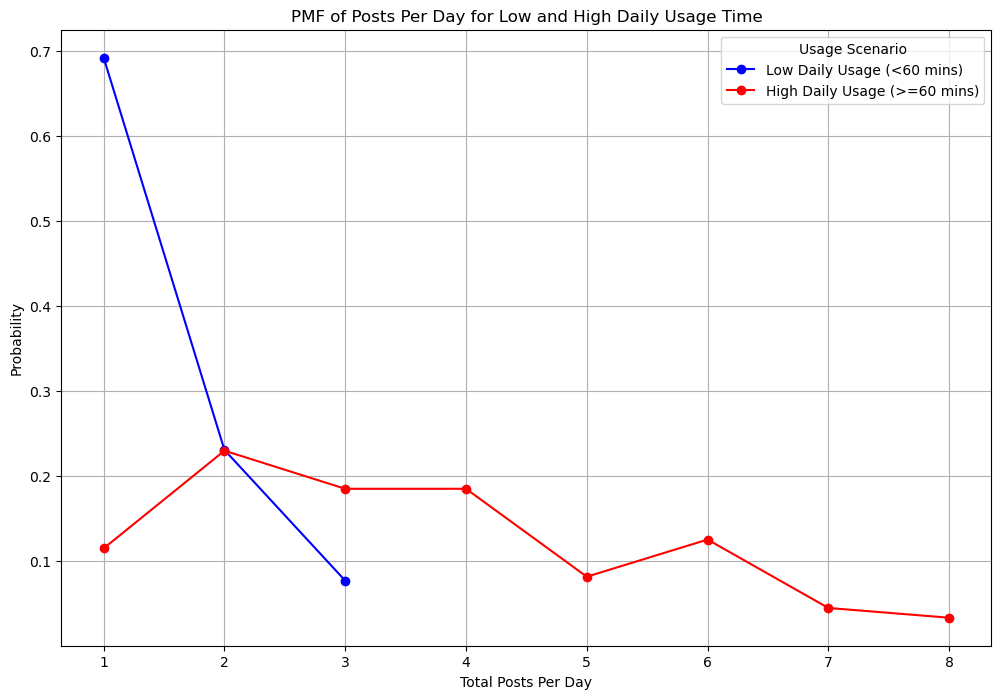

In [102]:
# Plot the PMF for high posting users
plt.figure(figsize=(12,8))
plt.plot(pmf_low_usage.index, pmf_low_usage.values, 'bo-', label='Low Daily Usage (<60 mins)')
plt.plot(pmf_high_usage.index, pmf_high_usage.values, 'ro-', label='High Daily Usage (>=60 mins)')

plt.title('PMF of Posts Per Day for Low and High Daily Usage Time')
plt.xlabel('Total Posts Per Day')
plt.ylabel('Probability')
plt.legend(title='Usage Scenario')
plt.grid(True)
plt.show()

In [ ]:
# Users with higher daily usage (red line) tend to post more frequently and show a broader range of posting behavior.
# Users with lower daily usage (blue line) are more consistent in their limited interaction, mostly posting once per day.
# People who spend less than 60 minutes per day on social media are most likely to post once per day with a probability around 70%.
# People who spend more than 60 minutes per day on social media have more varied posting behavior.  The highest probability is for 2 posts per day with
# a probability around 20%.
# Users who spend more time on social media not only post more frequently but also show a more diverse range of posting behavior.  

In [ ]:
# CDF

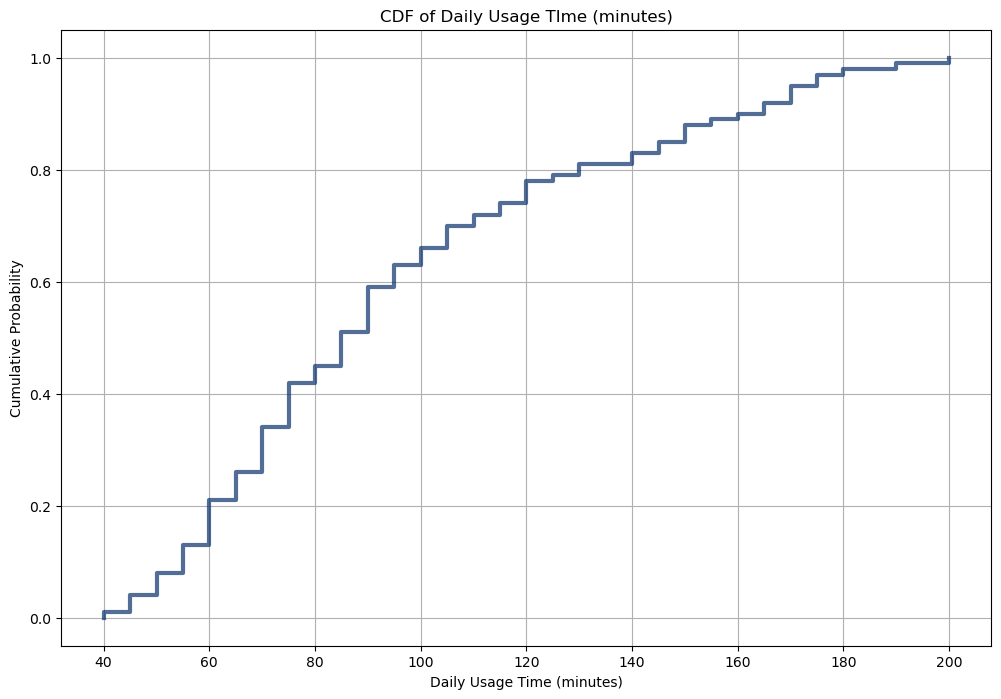

In [130]:
# Extract the Daily Usage Time (minutes)
daily_usage_time = data_clean['Daily_Usage_Time (minutes)']
# Create a CDF for daily usage time
cdf_daily_usage_time = thinkstats2.Cdf(daily_usage_time, label= 'Daily Usage Time (minutes)')

# Plot the CDF
plt.figure(figsize=(12,8))
thinkplot.Cdf(cdf_daily_usage_time)
plt.title('CDF of Daily Usage TIme (minutes)')
plt.xlabel('Daily Usage Time (minutes)')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.show()

In [ ]:
# The CDF shows the cumulative probability of users spending up to a certain amount of time on social media each day.
# The CDF increases steadily showing that as daily usage time increases, the cumulative probability also increases.  
# At 100 minutes the CDF is at about 50% which means that 50% of users spend 90 minutes or less on social media daily.  
# At 120 minutes the CDF is at about 75% which means that 75% of users spend 120 minutes or less on social media daily.  
# At 200 minutes the CDF is at about 100% which means that 100% of users spend 200 minutes or less on social media daily.  
# By understanding the distribution of daily usage time, we can relate it user engagement metrics to analyze if higher usage times correlate 
# with higher engagement levels.
# Most users spend 60-120 minutes a day on social media.  

In [ ]:
# ANALYTICAL DISTRIBUTION

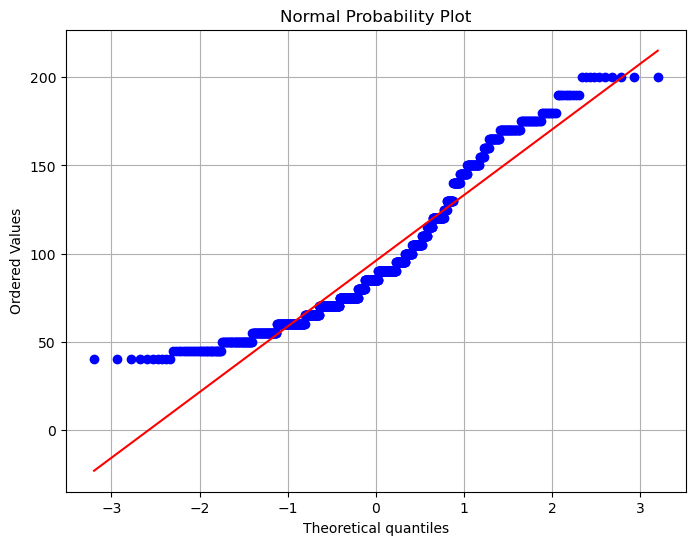

In [64]:
import scipy.stats as stats
# Generate the normal probability plot
plt.figure(figsize=(8,6))
stats.probplot(daily_usage_time, dist="norm", plot=plt)
plt.title('Normal Probability Plot')
plt.grid(True)
plt.show()

In [ ]:
# The Daily Usage Time does not perfectly follow a normal distribution.  It shows skewness and heavier tails as is common in real world data.
# The presence of skewness and tail suggests some users spend significantly more or less time on social media which could correlate with engagement
# levels.

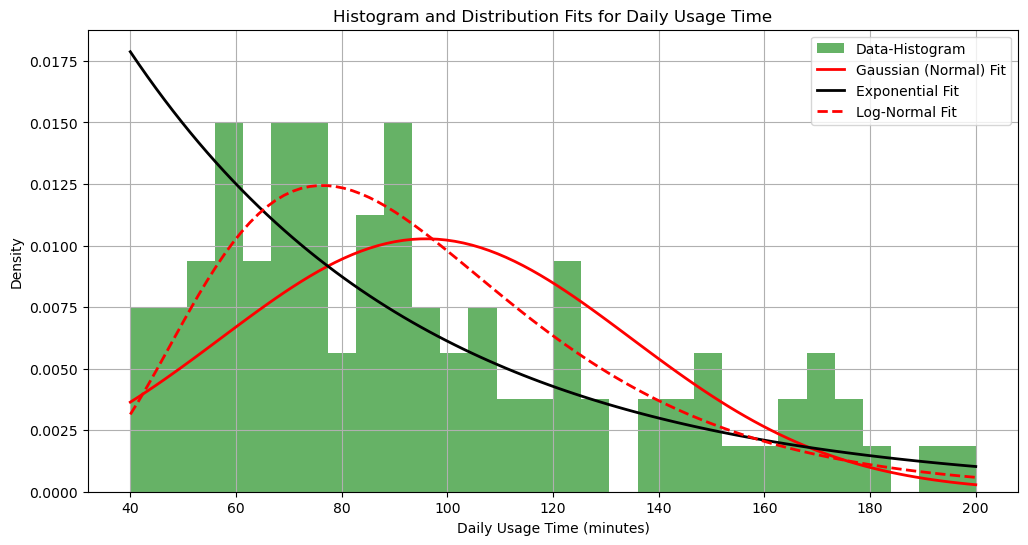

((95.95, 38.83101209085336),
 (40.0, 55.95),
 (0.3894558056969765, 0, 88.83146930852736))

In [104]:
# Fit Gaussian, Exponential and Log-Normal Distribution
gaussian_params = stats.norm.fit(daily_usage_time)
exponential_params = stats.expon.fit(daily_usage_time)
lognorm_params = stats.lognorm.fit(daily_usage_time, floc=0)

plt.figure(figsize=(12,6))
plt.hist(daily_usage_time, bins=30, density=True, alpha = 0.6, color='g', label='Data-Histogram')

# Gaussian Distribution
x=np.linspace(daily_usage_time.min(), daily_usage_time.max(),100)
gaussian_pdf = stats.norm.pdf(x, *gaussian_params)
plt.plot(x, gaussian_pdf, 'r-', lw=2, label='Gaussian (Normal) Fit')

# Exponential Distribution
exponential_pdf= stats.expon.pdf(x, *exponential_params)
plt.plot(x,exponential_pdf,'k-', lw=2, label='Exponential Fit')

# Log-Normal Distribution
lognorm_pdf= stats.lognorm.pdf(x, *lognorm_params)
plt.plot(x,lognorm_pdf,'r--', lw=2, label='Log-Normal Fit')

plt.title('Histogram and Distribution Fits for Daily Usage Time')
plt.xlabel('Daily Usage Time (minutes)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

gaussian_params, exponential_params, lognorm_params

In [ ]:
# Daily usage time is better modeled by a log-normal distribution than a normal or exponential distribution. This means that
# traditional parametric tests may not be appropriate and there are significant deviations in user behavior.  The presence of multiple
# peaks and skewness suggests that daily social media time may be influenced by other factors leading to a distribution that is not well described
# by simple or exponential distribution.

In [ ]:
# SCATTER PLOT

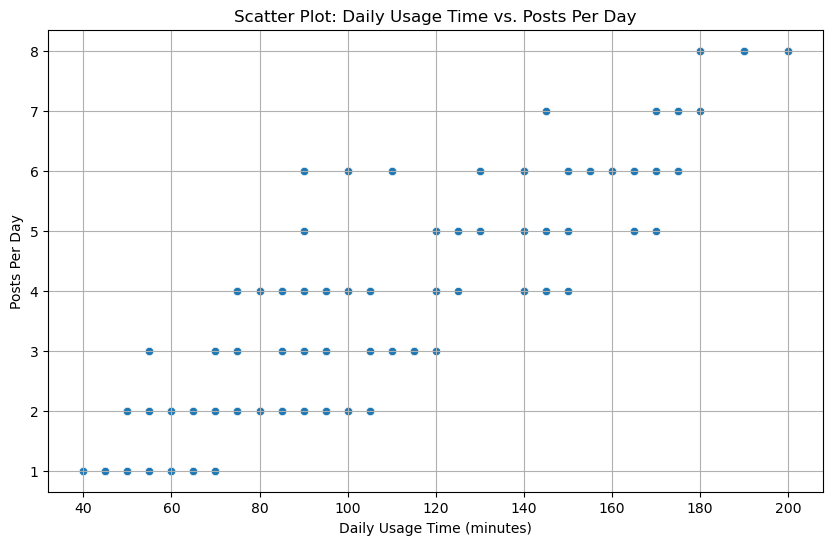

PearsonRResult(statistic=0.889205318294818, pvalue=0.0)

In [110]:
# Scatter plot for daily usage time vs. posts per day
import seaborn as sns
from scipy.stats import pearsonr

plt.figure(figsize=(10,6))
sns.scatterplot(x='Daily_Usage_Time (minutes)', y='Posts_Per_Day', data=data_clean)
plt.title('Scatter Plot: Daily Usage Time vs. Posts Per Day')
plt.xlabel('Daily Usage Time (minutes)')
plt.ylabel('Posts Per Day')
plt.grid(True)
plt.show()

# Calculate Pearson correlation coefficient
corr_posts = pearsonr(data_clean['Daily_Usage_Time (minutes)'], data_clean['Posts_Per_Day'])
corr_posts

In [ ]:
# There is a clear upward trend in the scatterplot which indicates that as daily usage time increases, the number of posts
# also increases.
# The Pearson correlation coefficient is approximately 0.889.  Since this value is close to 1, it indicates a strong positive
# linear relationship between daily usage time and posts per day.  The p-value is 0.0 indicating the result is statistically 
# significant.
# The correlation is strong but does not imply causation.  Other factors could influence the variables.  

In [ ]:
# REGRESSION ANALYSIS

                                OLS Regression Results                                
Dep. Variable:     Daily_Usage_Time (minutes)   R-squared:                       0.908
Model:                                    OLS   Adj. R-squared:                  0.907
Method:                         Least Squares   F-statistic:                     2449.
Date:                        Wed, 31 Jul 2024   Prob (F-statistic):               0.00
Time:                                19:37:55   Log-Likelihood:                -3886.4
No. Observations:                        1000   AIC:                             7783.
Df Residuals:                             995   BIC:                             7807.
Df Model:                                   4                                         
Covariance Type:                    nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

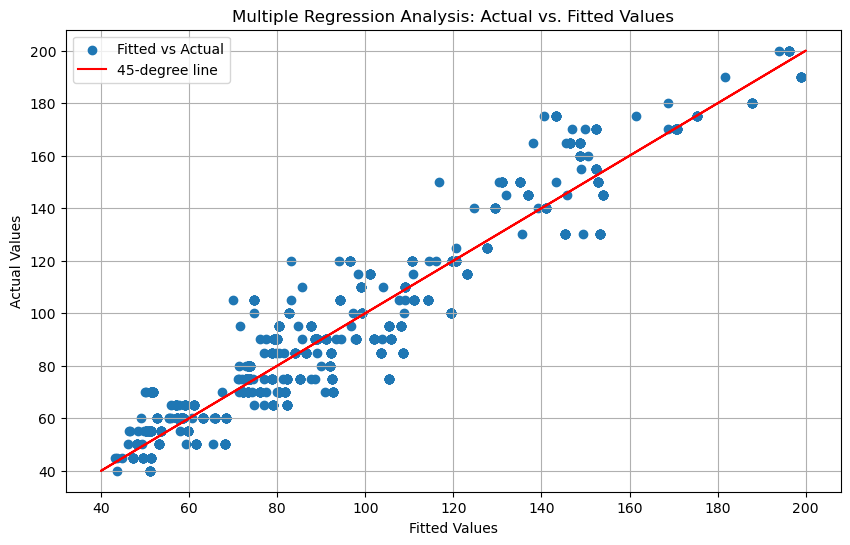

In [144]:
# Import libraries for statistical modeling and plotting
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Define x and y variables
Y = data_clean['Daily_Usage_Time (minutes)']
X = data_clean[['Posts_Per_Day', 'Likes_Received_Per_Day', 'Comments_Received_Per_Day', 'Messages_Sent_Per_Day']]

# Add constant to independent variables matrix x
X = sm.add_constant(X)

# Fitting an ordinary least squares regression model using y as the dependent variable
model = sm.OLS(Y, X).fit()

# Print the summary of regression model
print(model.summary())

# Plotting actual vs fitted to visualize model performance
plt.figure(figsize=(10,6))
plt.scatter(model.fittedvalues, Y, label='Fitted vs Actual')
plt.plot(Y, Y, color='red', label='45-degree line')
plt.title('Multiple Regression Analysis: Actual vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Actual Values')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# The regression mode explains 90.8% of the variability in daily social media usage time which indicates a strong fit.  Key indicators of posts per day,
# likes per day, and messages per day significantly increase daily usage time.  Comments per day are not statistically significant.  The model's 
# predictions align well with actual usage times shown by the scatter plot which comfirms its reliability.

In [ ]:
# HYPOTHESIS TEST

In [178]:
# Define class for hypothesis testing
class HypothesisTest(object):
    
    # Initialize class with data and prepare the model
    def __init__(self, data):
        self.data = data
        self.MakeModel()
        self.actual = self.TestStatistic(data)

    # Caclulate p-value using permutation testing
    def PValue (self, iters = 1000):
        self.test_stats =[self.TestStatistic(self.RunModel())
                          for _ in range(iters)]
        count = sum(1 for x in self.test_stats if x >= self.actual)
        return count / iters

    # Calculate test statistic for the given data
    def TestStatistic (self, data):
        model = sm.OLS(data_clean['Daily_Usage_Time (minutes)'], sm.add_constant(data[['Posts_Per_Day', 'Likes_Received_Per_Day', 'Comments_Received_Per_Day', 'Messages_Sent_Per_Day']])).fit()
        return np.abs(model.tvalues[1:]).mean()

    # Prepare model
    def MakeModel(self):
        self.model_data = self.data.copy()

    #Permute daily usage time data
    def RunModel(self):
        permuted_data = self.model_data.copy()
        permuted_data['Daily_Usage_Time (minutes)'] = np.random.permutation(permuted_data['Daily_Usage_Time (minutes)'])
        return permuted_data

# Instantiate the HypothesisTest with the data and calculate the p-value
ht = HypothesisTest(data_clean)
p_value = ht.PValue(iters = 1000)
print(f"P-value for the hypothesis test: {p_value}")

P-value for the hypothesis test: 1.0


In [ ]:
# The p-value for the hypothesis test was 1.0.  This indicates that the test statistic is not significantly different from what
# would be expected under the null hypothesis.  This means there is not evidence to reject the null hypothesis.